In [1]:
import pandas as pd

In [2]:
file = "./../data/songs_with_attributes_and_lyrics.csv"
df = pd.read_csv(file)

df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.6050,7,-11.157,1,0.0575,0.00116,0.838000,0.4710,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou..."
1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.6480,7,-9.135,0,0.3150,0.90000,0.000000,0.1760,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n..."
2,69lcggVPmOr9cvPx9kLiiN,!!! - Interlude,Where I Belong EP,Glowie,0.000,0.0354,7,-20.151,0,0.0000,0.90800,0.000000,0.4790,0.000,0.000,11413.0,"Oh, my God, I'm going crazy\n"
3,4U7dlZjg1s9pjdppqZy0fm,!!De Repente!!,Un Palo Al Agua (20 Grandes Canciones),Rosendo,0.657,0.8820,5,-6.340,1,0.0385,0.00740,0.000013,0.0474,0.939,123.588,198173.0,Continuamente se extraña la gente si no puede ...
4,4v1IBp3Y3rpkWmWzIlkYju,!!De Repente!!,Fuera De Lugar,Rosendo,0.659,0.8930,5,-8.531,1,0.0411,0.09220,0.000019,0.0534,0.951,123.600,199827.0,Continuamente se extraña la gente si no puede ...


In [3]:
df.columns

Index(['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics'],
      dtype='str')

In [4]:
df.shape

(955320, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 955320 entries, 0 to 955319
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                955320 non-null  str    
 1   name              955309 non-null  str    
 2   album_name        385557 non-null  str    
 3   artists           955315 non-null  str    
 4   danceability      955320 non-null  float64
 5   energy            955320 non-null  float64
 6   key               955320 non-null  str    
 7   loudness          955320 non-null  float64
 8   mode              955320 non-null  str    
 9   speechiness       955320 non-null  float64
 10  acousticness      955320 non-null  float64
 11  instrumentalness  955320 non-null  float64
 12  liveness          955320 non-null  float64
 13  valence           955320 non-null  float64
 14  tempo             955320 non-null  float64
 15  duration_ms       955320 non-null  float64
 16  lyrics            955307 non-nu

In [6]:
df.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,955320.000000,955320.000000,955320.000000,955320.000000,955320.000000,955320.000000,955320.000000,955320.000000,955320.000000,9.553200e+05
mean,0.550710,0.652442,-7.833732,0.083638,0.282962,0.081875,0.220190,0.488119,122.226093,2.341441e+05
std,0.169784,0.238824,3.792018,0.092929,0.311800,0.212789,0.195938,0.251468,29.536303,9.068368e+04
min,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.586000e+03
25%,0.436000,0.482000,-9.750000,0.034500,0.011900,0.000000,0.098900,0.282000,99.021000,1.849330e+05
50%,0.558000,0.687000,-7.041000,0.047800,0.142000,0.000039,0.137000,0.477000,120.661000,2.213070e+05
75%,0.675000,0.857000,-5.148000,0.087625,0.518000,0.008660,0.285000,0.690000,140.094000,2.656400e+05
max,0.993000,1.000000,4.882000,0.966000,0.996000,1.000000,1.000000,1.000000,246.130000,5.764624e+06


In [7]:
df.isnull().sum()

id                       0
name                    11
album_name          569763
artists                  5
danceability             0
energy                   0
key                      0
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness         0
liveness                 0
valence                  0
tempo                    0
duration_ms              0
lyrics                  13
dtype: int64

In [8]:
features = [
    "danceability",
    "loudness",
    "key",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
]
target = "energy"

df_model = df[features + [target]]

In [9]:
df_model.shape

(955320, 12)

In [10]:
df_model.isnull().sum()

danceability        0
loudness            0
key                 0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
energy              0
dtype: int64

In [11]:
X = df_model.drop(columns=['energy'])
y = df_model["energy"]

In [12]:
print(X.shape)
print(y.shape)

(955320, 11)
(955320,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(764256, 11)
(191064, 11)
(764256,)
(191064,)


In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'E'

In [16]:
print(X.dtypes)

danceability        float64
loudness            float64
key                     str
mode                    str
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms         float64
dtype: object


In [17]:
for col in X.columns:
    print(col, X[col].unique()[:10])

danceability [0.415 0.788 0.    0.657 0.659 0.171 0.823 0.729 0.6   0.53 ]
loudness [-11.157  -9.135 -20.151  -6.34   -8.531  -5.749  -7.767  -8.562 -11.803
  -7.502]
key <StringArray>
['7', '5', '2', '1', '9', '0', '4', 'F', '6', '8']
Length: 10, dtype: str
mode <StringArray>
['1', '0', 'Major', '1.0', 'Minor', '0.0']
Length: 6, dtype: str
speechiness [0.0575 0.315  0.     0.0385 0.0411 0.149  0.248  0.065  0.0328 0.037 ]
acousticness [1.16e-03 9.00e-01 9.08e-01 7.40e-03 9.22e-02 2.88e-05 1.68e-01 1.83e-01
 5.25e-01 3.18e-03]
instrumentalness [8.38e-01 0.00e+00 1.27e-05 1.91e-05 3.24e-05 3.05e-03 7.40e-06 3.94e-03
 9.10e-01 2.84e-02]
liveness [0.471  0.176  0.479  0.0474 0.0534 0.33   0.109  0.131  0.1    0.593 ]
valence [0.193 0.287 0.    0.939 0.951 0.349 0.688 0.38  0.547 0.819]
tempo [100.059  79.998   0.    123.588 123.6   175.317 142.959  86.103 125.898
 120.179]
duration_ms [ 79500. 114000.  11413. 198173. 199827. 197400. 178533. 186197. 220560.
 121170.]


In [18]:
categorical_features = ["key", "mode"]
numerical_features = [
    "danceability",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

In [21]:
import numpy as np

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

In [22]:
print(X_train_processed.mean(axis=0))
print(X_train_processed.std(axis=0))

[ 9.68682503e-17  5.93142799e-17  5.40784409e-17 -3.29428949e-18
 -7.40882391e-15  5.68363629e-17 -1.17203767e-16  8.27568933e-16
 -1.77643732e-17  9.71807876e-02  1.29995708e-02  7.27622681e-02
  1.11193108e-02  5.09253444e-02  7.16513838e-03  6.36645313e-02
  9.17624461e-03  9.08360549e-02  1.16662480e-02  2.53239752e-02
  3.73173387e-03  6.76972114e-02  8.93548759e-03  6.57489114e-02
  9.23381694e-03  5.09986183e-02  7.72908554e-03  9.89158083e-02
  1.28098438e-02  4.92217268e-02  7.40197002e-03  9.02681824e-02
  1.14477348e-02  6.41538961e-03  4.00389398e-03  5.34245070e-03
  7.39673617e-03  6.28323494e-03  6.18379182e-03  1.83446384e-03
  4.74055814e-03  5.06374827e-03  4.33886028e-03  7.26850689e-03
  4.16876021e-03  2.75615762e-01  4.05256877e-02  5.47927658e-01
  7.28904974e-02  4.12859042e-02  2.17544906e-02]
[1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.29620378 0.11327216 0.25974588
 0.10486025 0.21984529 0.08434334 0.24415437

In [23]:
import torch

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

In [24]:
print(type(X_train_tensor))
print(X_train_tensor.shape)

print(type(y_train_tensor))
print(y_train_tensor.shape)

<class 'torch.Tensor'>
torch.Size([764256, 51])
<class 'torch.Tensor'>
torch.Size([764256, 1])


In [25]:
print(X_train_tensor[0])

tensor([ 0.9023, -1.1932, -0.5255,  0.0280, -0.3845, -0.9099,  1.7795,  2.6265,
        -0.9623,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000])


In [26]:
print(X_train_tensor[0].shape)

torch.Size([51])


In [27]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_train_tensor[0])
print(y_train_tensor[0])

torch.Size([764256, 51])
torch.Size([764256, 1])
tensor([ 0.9023, -1.1932, -0.5255,  0.0280, -0.3845, -0.9099,  1.7795,  2.6265,
        -0.9623,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000])
tensor([0.4790])


In [28]:
print(X_train_tensor.shape[1])

51


In [29]:
import torch

num_features = X_train_tensor.shape[1]

weights = torch.randn(num_features, 1)

bias = torch.randn(1)

print(weights.shape)
print(bias.shape)

torch.Size([51, 1])
torch.Size([1])


In [30]:
print(weights[0], weights[10], weights[30])

tensor([2.2067]) tensor([0.2698]) tensor([-0.8226])


In [31]:
sample = X_train_tensor[0]

prediction = torch.matmul(sample, weights).item() + bias.item()

print(prediction)

5.377811938524246


In [32]:
print(y_train_tensor[0])

tensor([0.4790])


In [33]:
actual = 0.479

loss = (prediction - actual) ** 2

print(loss)

23.99835840902768


In [ ]:
epsilon = 0.001
original_loss = 23.99835

row_index = 0

print("original weight", weights[row_index])
weights[row_index] += epsilon
print("new weight", weights[row_index])

sample = X_train_tensor[0]

prediction = torch.matmul(sample, weights).item() + bias.item()
print("pred", prediction)
print("actual", actual)

loss = (prediction - actual) ** 2
print("loss function", loss)

new_loss = loss

gradient = (new_loss - original_loss) / epsilon
print("grad", gradient)

weights[row_index] -= epsilon
print("original weight", weights[row_index])

original weight tensor([2.2067])
new weight tensor([2.2077])
pred 5.3787141144275665
actual 0.479
loss function 24.00719840312071
grad 8.848403120712334
original weight tensor([2.2067])


In [36]:
epsilon = 0.001
original_loss = 23.99835

row_index = 10

print("original weight", weights[row_index])
weights[row_index] += epsilon
print("new weight", weights[row_index])

sample = X_train_tensor[0]

prediction = torch.matmul(sample, weights).item() + bias.item()
print("pred", prediction)
print("actual", actual)

loss = (prediction - actual) ** 2
print("loss function", loss)

new_loss = loss

gradient = (new_loss - original_loss) / epsilon
print("grad", gradient)

weights[row_index] -= epsilon
print("original weight", weights[row_index])

original weight tensor([0.2698])
new weight tensor([0.2708])
pred 5.377811938524246
actual 0.479
loss function 23.99835840902768
grad 0.008409027682176884
original weight tensor([0.2698])


In [41]:
epsilon = 0.001
original_loss = 23.99835

row_index = 0

print("original weight", weights[row_index])
weights[row_index] += epsilon
print("new weight", weights[row_index])

sample = X_train_tensor[0]

prediction = torch.matmul(sample, weights).item() + bias.item()
print("pred", prediction)
print("actual", actual)

loss = (prediction - actual) ** 2
print("loss function", loss)

new_loss = loss

gradient = (new_loss - original_loss) / epsilon
print("grad", gradient)

weights[row_index] -= epsilon
print("original weight", weights[row_index])

original weight tensor([-0.3258], grad_fn=<SelectBackward0>)


RuntimeError: a view of a leaf Variable that requires grad is being used in an in-place operation.

In [46]:
weights = torch.randn(
    (51,1),
    requires_grad=True,
    dtype=torch.float32
)

bias = torch.randn(
    1,
    requires_grad=True,
)

In [40]:
sample = X_train_tensor[0]
prediction = sample @ weights + bias

actual = y_train_tensor[0]
loss = (prediction - actual) ** 2

loss.backward()

print(weights.grad[:5])
print(bias.grad)

tensor([[ 5.3711],
        [-7.1028],
        [-3.1285],
        [ 0.1665],
        [-2.2887]])
tensor([5.9529])


In [42]:
learning_rate = 0.01
with torch.no_grad():
    weights -= learning_rate*weights.grad
    bias -= learning_rate * bias.grad

In [43]:
weights.grad.zero_()
bias.grad.zero_()

tensor([0.])

In [48]:
learning_rate = 0.001
iteration = 100

sample = X_train_tensor[0]

for i in range(iteration):
    
	prediction = sample @ weights + bias

	actual = y_train_tensor[0]
	loss = (prediction - actual) ** 2

	if i%10 == 0:
		print(f"iteration {i} - loss {loss.item():.6f}")

	loss.backward()

	with torch.no_grad():
		weights -= learning_rate*weights.grad
		bias -= learning_rate * bias.grad
	
	weights.grad.zero_()
	bias.grad.zero_()

iteration 0 - loss 0.396094
iteration 10 - loss 0.184739
iteration 20 - loss 0.090665
iteration 30 - loss 0.044496
iteration 40 - loss 0.021837
iteration 50 - loss 0.010717
iteration 60 - loss 0.005260
iteration 70 - loss 0.002581
iteration 80 - loss 0.001267
iteration 90 - loss 0.000622


In [49]:
import torch

x = torch.tensor([-5., -2., -1., 0., 1., 4., 8.])

relu = torch.maximum(x, torch.tensor(0.0))

print(relu)

tensor([0., 0., 0., 0., 1., 4., 8.])


In [51]:
torch.relu(x)

tensor([0., 0., 0., 0., 1., 4., 8.])

In [52]:
import torch.nn as nn

model_linear = nn.Sequential(
    nn.Linear(51, 3),
    nn.Linear(3, 1)
)

In [53]:
model_relu = nn.Sequential(
    nn.Linear(51, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

In [54]:
print(model_linear)
print(model_relu)

Sequential(
  (0): Linear(in_features=51, out_features=3, bias=True)
  (1): Linear(in_features=3, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=51, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
)


In [55]:
import torch.nn as nn

class EnergyPredictor(nn.Module):
    
	def __init__(self, hidden_size=2, use_relu=False):
		super().__init__()

		layers = [
			nn.Linear(51, hidden_size)
		]

		if use_relu:
			layers.append(nn.ReLU())
		
		layers.append(
			nn.Linear(hidden_size, 1)
		)

		self.network = nn.Sequential(*layers)

	def forward(self, x):
		return self.network(x)

In [56]:
model_a = EnergyPredictor(hidden_size=2, use_relu=False)

model_b = EnergyPredictor(hidden_size=2, use_relu=True)

model_c = EnergyPredictor(hidden_size=32, use_relu=False)

model_d = EnergyPredictor(hidden_size=32, use_relu=True)

In [65]:
criterion = nn.MSELoss()

optimizer_a = torch.optim.Adam(
    model_a.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):

    prediction = model_a(X_train_tensor)

    loss = criterion(prediction, y_train_tensor)
    if epoch%10 == 0:
        print(loss.item())

    optimizer_a.zero_grad()

    loss.backward()

    optimizer_a.step()

0.04050494730472565
0.02598530612885952
0.01867690309882164
0.016073452308773994
0.015097285620868206
0.014413299970328808
0.013968202285468578
0.013712974265217781
0.013542735949158669
0.013432007282972336


In [66]:
criterion = nn.MSELoss()

optimizer_d = torch.optim.Adam(
    model_d.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):

    prediction = model_d(X_train_tensor)

    loss = criterion(prediction, y_train_tensor)
    if epoch%10 == 0:
        print(loss.item())

    optimizer_d.zero_grad()

    loss.backward()

    optimizer_d.step()

0.023205969482660294
0.019041521474719048
0.016328737139701843
0.014600633643567562
0.013531799428164959
0.012868364341557026
0.012389645911753178
0.011989187449216843
0.01164458692073822
0.011364095844328403


In [67]:
model_d.network[0].weight.shape

torch.Size([32, 51])

In [68]:
from torch.utils.data import Dataset

class SpotifyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [79]:
train_dataset = SpotifyDataset(
    X_train_tensor,
    y_train_tensor
)

print(len(train_dataset))

764256


In [80]:
x, y = train_dataset[10]

print(x.shape)
print(y)

torch.Size([51])
tensor([0.6640])


In [84]:
from torch.utils.data import DataLoader, Subset

small_dataset = Subset(
    train_dataset,
    range(50000)
)

train_loader = DataLoader(
    small_dataset,
    batch_size=128,
    shuffle=True
)

In [85]:
for X_batch, y_batch in train_loader:

    print(X_batch.shape)

    print(y_batch.shape)

    break

torch.Size([128, 51])
torch.Size([128, 1])


In [86]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_a.parameters(),
    lr=0.001
)

epochs = 20

for epoch in range(epochs):
	model_a.train()
	
	epoch_loss = 0
    
	for X_batch, y_batch in train_loader:

		prediction = model_a(X_batch)

		loss = criterion(
			prediction,
			y_batch
		)

		optimizer.zero_grad()

		loss.backward()

		optimizer.step()
		
		epoch_loss += loss.item()

	avg_loss = epoch_loss / len(train_loader)

	if epoch%5 == 0:
		print(f"epoch: {epoch:3d} loss: {avg_loss:.6f}")


epoch:   0 loss: 5.520264
epoch:   5 loss: 0.060469
epoch:  10 loss: 0.056298
epoch:  15 loss: 0.047890


In [87]:
print(next(model_a.parameters()).device)

print(X_batch.device)

print(loss.item())

cpu
cpu
0.034886330366134644


In [88]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Ti


In [95]:
def train_model(model, train_loader, epochs: int = 20, lr: float = 0.001, device: str='cpu'):
	model.to(device)

	criterion = nn.MSELoss()
	
	optimizer = torch.optim.Adam(
		model.parameters(),
		lr = lr
	)

	# device = torch.device(
	# 	"cuda" if torch.cuda.is_available()
	# 	else "cpu"
	# )
	
	train_losses = []
	
	for epoch in range(epochs):
		model.train()
		
		epoch_loss = 0
		
		for X_batch, y_batch in train_loader:

			X_batch = X_batch.to(device)
			y_batch = y_batch.to(device)

			prediction = model(X_batch)

			loss = criterion(
				prediction,
				y_batch
			)

			optimizer.zero_grad()

			loss.backward()

			optimizer.step()
			
			epoch_loss += loss.item()

		avg_loss = epoch_loss / len(train_loader)

		train_losses.append(avg_loss)

		if epoch%5 == 0:
			print(f"Epoch: {epoch:2d}/{epochs} ; Loss: {avg_loss:.5f}")
	return model, train_losses


In [90]:
from torch.utils.data import DataLoader

test_dataset = SpotifyDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=True
)

In [ ]:

history = train_model(
    model=model_a,
    train_loader=train_loader,
    epochs=20,
    lr=0.001
)

epoch:   0 loss: 0.024095
epoch:   5 loss: 0.015328
epoch:  10 loss: 0.014099
epoch:  15 loss: 0.013705


In [93]:
torch.manual_seed(42)

In [94]:
torch.manual_seed(42)
model_a = EnergyPredictor(hidden_size=2, use_relu=False)
torch.manual_seed(42)
model_b = EnergyPredictor(hidden_size=2, use_relu=True)
torch.manual_seed(42)
model_c = EnergyPredictor(hidden_size=32, use_relu=False)
torch.manual_seed(42)
model_d = EnergyPredictor(hidden_size=32, use_relu=True)

In [98]:
def train_and_validate_model(model, train_loader, val_loader, epochs: int = 20, lr: float = 0.001, device: str='cpu'):
	model.to(device)

	criterion = nn.MSELoss()
	
	optimizer = torch.optim.Adam(
		model.parameters(),
		lr = lr
	)

	# device = torch.device(
	# 	"cuda" if torch.cuda.is_available()
	# 	else "cpu"
	# )
	train_losses = []
	val_losses = []
	

	for epoch in range(epochs):
		model.train()
		epoch_loss = 0
		for X_batch, y_batch in train_loader:

			X_batch = X_batch.to(device)
			y_batch = y_batch.to(device)

			prediction = model(X_batch)

			loss = criterion(
				prediction,
				y_batch
			)

			optimizer.zero_grad()

			loss.backward()

			optimizer.step()
			
			epoch_loss += loss.item()

		avg_loss = epoch_loss / len(train_loader)
		train_losses.append(avg_loss)

		model.eval()
		val_loss = 0
		with torch.no_grad():
			for X_batch, y_batch in val_loader:
				X_batch = X_batch.to(device)
				y_batch = y_batch.to(device)

				prediction = model(X_batch)
				loss = criterion(
					prediction,
					y_batch
				)
				val_loss += loss.item()

		avg_val_loss = val_loss / len(val_loader)
		val_losses.append(avg_val_loss)

		if epoch%5 == 0:
			print(f"Epoch: {epoch:2d}/{epochs} ; Train Loss: {avg_loss:.5f} ; Val Loss: {avg_val_loss:.5f}")
	
	

	return model, train_losses, val_losses


Epoch:  0/20 ; Train Loss: 0.01375 ; Val Loss: 0.01334
Epoch:  5/20 ; Train Loss: 0.01332 ; Val Loss: 0.01333
Epoch: 10/20 ; Train Loss: 0.01332 ; Val Loss: 0.01331
Epoch: 15/20 ; Train Loss: 0.01332 ; Val Loss: 0.01332


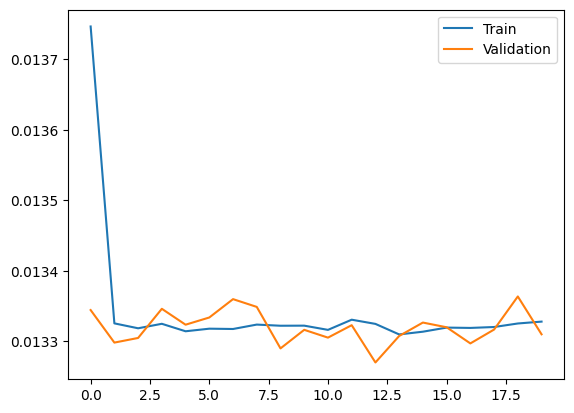

In [99]:
import matplotlib.pyplot as plt
_, train_losses, val_losses = train_and_validate_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    lr=0.001
)

plt.plot(train_losses)

plt.plot(val_losses)

plt.legend(["Train","Validation"])

Epoch:  0/20 ; Train Loss: 0.03870 ; Val Loss: 0.01348
Epoch:  5/20 ; Train Loss: 0.01345 ; Val Loss: 0.01348
Epoch: 10/20 ; Train Loss: 0.01346 ; Val Loss: 0.01351
Epoch: 15/20 ; Train Loss: 0.01346 ; Val Loss: 0.01338


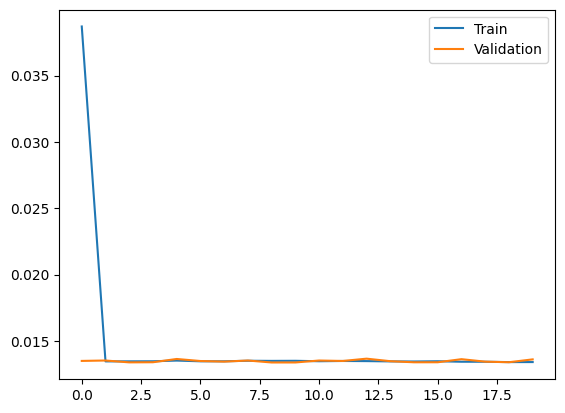

In [100]:
_, train_losses, val_losses = train_and_validate_model(
    model=model_c,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    lr=0.001
)

plt.plot(train_losses)

plt.plot(val_losses)

plt.legend(["Train","Validation"])

Epoch:  0/20 ; Train Loss: 0.80173 ; Val Loss: 0.13747
Epoch:  5/20 ; Train Loss: 0.01320 ; Val Loss: 0.01323
Epoch: 10/20 ; Train Loss: 0.01184 ; Val Loss: 0.01175
Epoch: 15/20 ; Train Loss: 0.01148 ; Val Loss: 0.01143


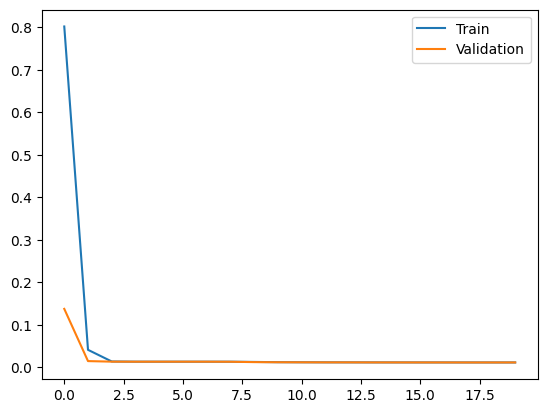

In [101]:
_, train_losses, val_losses = train_and_validate_model(
    model=model_b,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    lr=0.001
)

plt.plot(train_losses)

plt.plot(val_losses)

plt.legend(["Train","Validation"])

Epoch:  0/20 ; Train Loss: 0.04575 ; Val Loss: 0.01371
Epoch:  5/20 ; Train Loss: 0.01022 ; Val Loss: 0.01012
Epoch: 10/20 ; Train Loss: 0.00980 ; Val Loss: 0.00989
Epoch: 15/20 ; Train Loss: 0.00967 ; Val Loss: 0.00989


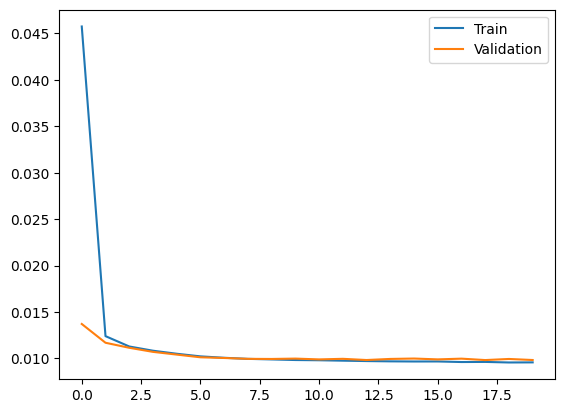

In [102]:
_, train_losses, val_losses = train_and_validate_model(
    model=model_d,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    lr=0.001
)

plt.plot(train_losses)

plt.plot(val_losses)

plt.legend(["Train","Validation"])

In [ ]:
from sklearn.metrics import r2_score

model.eval()

predictions = []

actuals = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        prediction = model(X_batch)

        predictions.extend(
            prediction.cpu().numpy()
        )

        actuals.extend(
            y_batch.cpu().numpy()
        )

r2 = r2_score(actuals, predictions)

print(r2)